In [1]:
import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import seaborn as sns

from advan_test import data
from advan_test.utils import project_root

# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

con = duckdb.connect()
con.install_extension("spatial")
con.load_extension("spatial")

In [2]:
ROOT = project_root()
DATA_PATH = ROOT / "data"
PARQUET_DIR_PATH = DATA_PATH / "2025-weekly-patterns-plus"
DATA_GLOB = PARQUET_DIR_PATH / "*.parquet"
CSV_PATH = DATA_PATH / "weekly-patterns-plus-sample.csv"
US_PATH = DATA_PATH / "us-states.json"
SHP_PATH = DATA_PATH / "tl_2025_04_bg" / "tl_2025_04_bg.shp"

In [3]:
con.execute(f"""
    CREATE OR REPLACE TABLE states AS
    SELECT * FROM ST_Read('{US_PATH}')
""")
con.execute(f"""
    CREATE OR REPLACE TABLE arizona_shp AS
    SELECT * FROM '{SHP_PATH}'
""")
con.execute(f"""
    CREATE OR REPLACE TABLE wpp_arizona AS
    WITH boundary AS (
        SELECT geom
        FROM states 
        WHERE name = 'Arizona'
    ), t AS (
        SELECT *
        FROM '{DATA_GLOB}'
    )
    SELECT t.*
    FROM t, boundary
    WHERE ST_Within(
        ST_Point(t.LONGITUDE, t.LATITUDE),
        boundary.geom
    )
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [4]:
lf = con.sql("SELECT * FROM wpp_arizona").pl().lazy()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

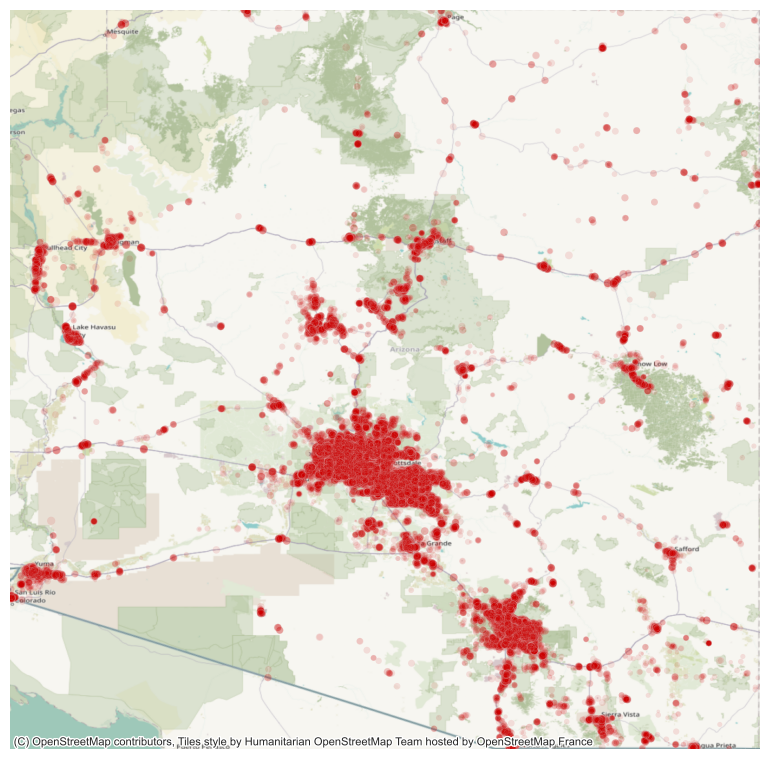

In [5]:
pois = lf.group_by("BRAND", "LONGITUDE", "LATITUDE").agg(
    pl.col("VISITOR_COUNTS").sum().cast(pl.Float64),
    pl.col("VISITOR_COUNTS").sum().log().cast(pl.Float64).alias("LOG_VISITOR_COUNTS")
).collect()
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
ax = sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="LOG_VISITOR_COUNTS", sizes=(1, 50),
    alpha=.1, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
cx.add_basemap(ax, crs="EPSG:4326", zoom=8)
ax.set_axis_off()
ax.set_aspect("equal")

<Axes: >

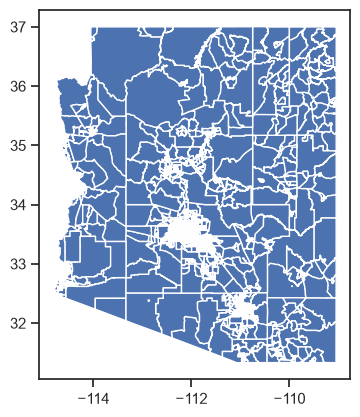

In [6]:
df = con.sql("SELECT * FROM arizona_shp").df()
df["geom"] = df["geom"].apply(bytes)
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.GeoSeries.from_wkb(df["geom"]), 
    crs="EPSG:4326"
)
gdf.plot()

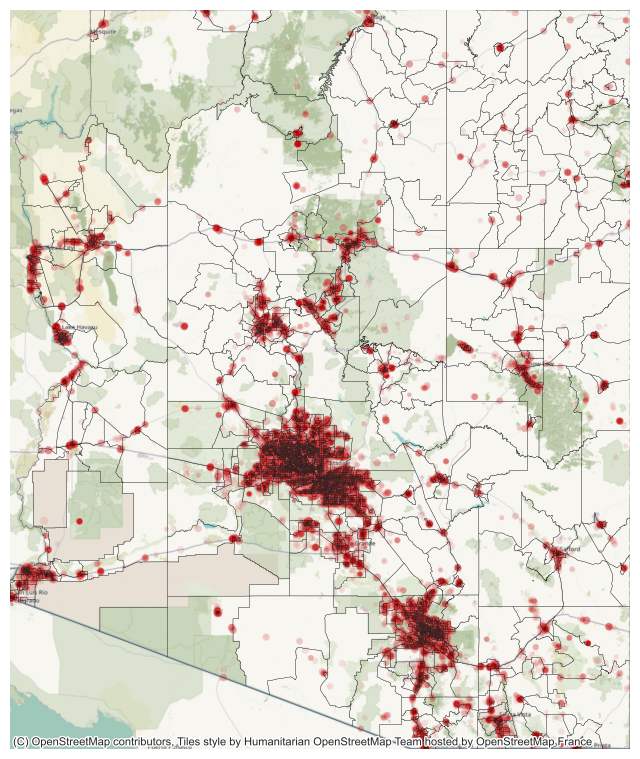

In [7]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
gdf.boundary.plot(ax=ax, color="#222", linewidth=0.2)
ax = sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="LOG_VISITOR_COUNTS", sizes=(1, 50),
    alpha=.1, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
cx.add_basemap(ax, crs="EPSG:4326", zoom=8)
ax.set_axis_off()

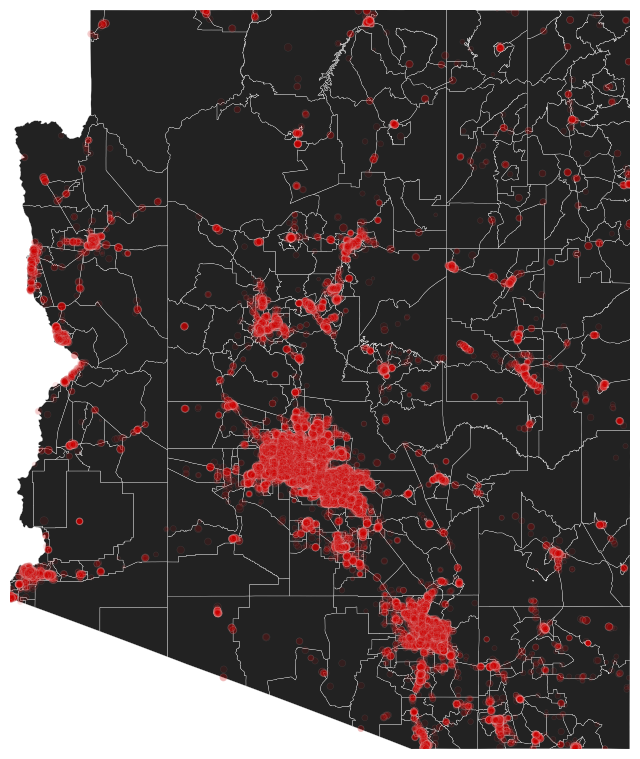

In [8]:
fig_scale = 2
fig, ax = plt.subplots(figsize=(6.4*fig_scale, 4.8*fig_scale))
gdf.plot(ax=ax, color="#222", linewidth=0.2)
ax = sns.scatterplot(
    pois, x="LONGITUDE", y="LATITUDE",
    color="#c00", size="LOG_VISITOR_COUNTS", sizes=(1, 50),
    alpha=.1, ax=ax, legend=False
)
ax.set_xlim(pois["LONGITUDE"].min(), pois["LONGITUDE"].max())
ax.set_ylim(pois["LATITUDE"].min(), pois["LATITUDE"].max())
ax.set_axis_off()

In [9]:
poi_od = con.sql(f"""
    SELECT 
        ID_STORE,
        UNNEST(map_keys(M)) AS HOME_CBG,
        POI_CBG,
        UNNEST(map_values(M)) AS VISITOR_COUNT
    FROM (
        SELECT *, CAST(VISITOR_HOME_CBGS::JSON AS MAP(VARCHAR, INTEGER)) AS M
        FROM wpp_arizona
    )
""").pl().lazy()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [10]:
od = (
    poi_od
        .filter(pl.col("HOME_CBG").str.starts_with("04"))
        .group_by("HOME_CBG", "POI_CBG")
        .agg(pl.col("VISITOR_COUNT").sum())
        .collect()
)
od_matrix = od.pivot(
    index="HOME_CBG",
    on="POI_CBG",
    values="VISITOR_COUNT"
).fill_null(0)

In [26]:
od.sample(10_000)

HOME_CBG,POI_CBG,VISITOR_COUNT
str,str,i32
"""040131044012""","""040131105012""",3192
"""040134226283""","""040131036124""",32
"""040130715043""","""040130719133""",170
"""040131127001""","""040179602004""",5
"""040131117002""","""040131042183""",15
…,…,…
"""040138133002""","""040131167282""",161
"""040138118001""","""040130610482""",161
"""040134222222""","""040131060032""",33


In [27]:
G = nx.DiGraph()
# Build (source, target, weight) tuples from the dataframe rows
edges = list(od.sample(10_000).iter_rows())  # [(HOME_CBG, POI_CBG, VISITOR_COUNT), ...]
G.add_weighted_edges_from(edges)

In [28]:
nx.number_of_no

NodeView(('040019426001', '040250003021', '040134211025', '040131042172', '040190040811', '040136152022', '040136149002', '040131034001', '040130820102', '040030006001', '040132171022', '040070003013', '040130820232', '040136148001', '040136117001', '040133200071', '040190028012', '040190040393', '040210014051', '040270109101', '040136157002', '040131032092', '040136163001', '040130405411', '040134212011', '040134207061', '040270009022', '040130928012', '040138163011', '040138134002', '040131080001', '040131083021', '040159548023', '040210003241', '040131049004', '040250016013', '040131092002', '040136189003', '040130610491', '040131138003', '040210002192', '040132177002', '040131063001', '040133198022', '040131045021', '040134205052', '040136150012', '040131173002', '040030015022', '040190040681', '040130506131', '040136138002', '040134225103', '040132182003', '040136119002', '040138143001', '040137233071', '040130830002', '040131042173', '040136178002', '040130719151', '040134221061'